# Reconstrucción de panel histórico de interacciones

## Qué hace este notebook

Toma un dataset de elecciones pasadas donde **cada fila es una publicación** y produce un **dataset ancho** con las interacciones estimadas día a día durante 14 días.

## Columnas de entrada esperadas

| Columna | Descripción |
|---------|-------------|
| `id_candidato` | Identificador del candidato |
| `red_social` | Plataforma |
| `fecha` | Fecha de publicación (dd/mm/yyyy) |
| `hora` | Hora de publicación (HH:MM:SS) |
| `usuario` | Nombre de usuario |
| `texto` | Texto |
| `url` | URL |
| `likes`, `comentarios`, `compartidos`, `vistas` | Totales finales |
| `fb_love`, `fb_haha`, `fb_care`, `fb_wow`, `fb_sad`, `fb_angry` | Reacciones Facebook |
| `favoritos` | Favoritos (Twitter) |

## Lógica de reconstrucción

Los modelos Weibull calibrados en Costa Rica 2026 definen la **forma** de la curva por plataforma. Con la hora exacta de publicación calculamos un `t0` individual:

$$t_0^{\text{post}} = \frac{23 - \text{hora\_pub}}{24}$$

Luego: `interacciones_acum_d{t} = total_final × F(t, t0_individual) / F(14, t0_individual)`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Parámetros del modelo

Cargados desde `weibull_params.csv` — el mismo CSV que produce `Modelado_Crecimiento_Interacciones_v4.ipynb`.
Para recalibrar: corre el notebook de modelado y reemplaza el CSV. El código aquí no cambia.

Parámetros cargados desde C:/Users/juansoag/Downloads/Github/Avances_tesis/Costa Rica/weibull_params.csv
                k   alpha  t0_base  mape_d3    calibrated_on  n_posts
platform                                                             
Facebook   0.9480  0.8230   1.9323     2.12  Costa Rica 2026      765
Instagram  1.1369  0.5210   0.0408    12.06  Costa Rica 2026      603
TikTok     1.3272  0.5124   0.7887     5.94  Costa Rica 2026      344
Twitter    1.4453  1.1422   0.2566     0.38  Costa Rica 2026      210


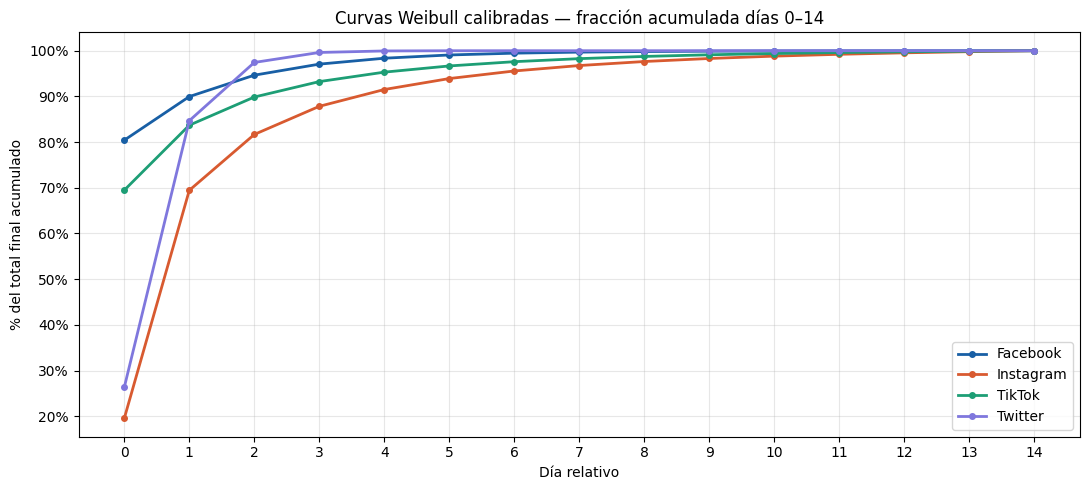

In [3]:
PARAMS_FILE = 'C:/Users/juansoag/Downloads/Github/Avances_tesis/Costa Rica/weibull_params.csv'  

params_df = pd.read_csv(PARAMS_FILE)
params_df = params_df.set_index('platform')

PLATFORM_PARAMS = {
    plat: {
        'k':       row['k'],
        'alpha':   row['alpha'],
        't0_base': row['t0_base'],
    }
    for plat, row in params_df.iterrows()
}

print('Parámetros cargados desde', PARAMS_FILE)
print(params_df[['k', 'alpha', 't0_base', 'mape_d3', 'calibrated_on', 'n_posts']].to_string())

PLATFORM_ALIASES = {
    'facebook': 'Facebook', 'instagram': 'Instagram',
    'tiktok': 'TikTok', 'twitter': 'Twitter',
    'x': 'Twitter', 'x (twitter)': 'Twitter',
}

INTERACTION_COLS = [
    ('likes', 'likes'), ('comentarios', 'comentarios'),
    ('compartidos', 'compartidos'), ('vistas', 'vistas'),
    ('favoritos', 'favoritos'), ('fb_love', 'fb_love'),
    ('fb_haha', 'fb_haha'), ('fb_care', 'fb_care'),
    ('fb_wow', 'fb_wow'), ('fb_sad', 'fb_sad'), ('fb_angry', 'fb_angry'),
]

META_COLS = ['id_candidato', 'red_social', 'fecha', 'hora',
             'usuario', 'texto', 'url']

DIAS = list(range(15))  # días 0 a 14

COLORS = {'Facebook': '#185FA5', 'Instagram': '#D85A30',
          'TikTok': '#1D9E75', 'Twitter': '#7F77DD'}

def weibull_offset(t, k, alpha, t0):
    return 1 - np.exp(-k * np.power(np.maximum(t + t0, 1e-9), alpha))

def compute_t0_individual(hora_str, t0_base):
    """
    t0 = t0_base (comportamiento estructural de la plataforma)
       + t0_hora (horas transcurridas desde publicación hasta medición nocturna ~23h)
    Ambos se suman porque son fenómenos independientes.
    Fallback si la hora no parsea: solo t0_base.
    """
    try:
        h = pd.to_datetime(str(hora_str), format='%H:%M:%S').hour
        t0_hora = max(0.0, (23 - h) / 24.0)
        return t0_base + t0_hora
    except Exception:
        return t0_base

def get_fractions(platform, t0):
    """
    Vector de fracciones F(0)..F(14) normalizado a F(14)=1
    usando el t0 individual de la publicación.
    """
    p = PLATFORM_PARAMS.get(platform)
    if p is None:
        all_f = np.array([
            [weibull_offset(t, q['k'], q['alpha'], t0) for t in DIAS]
            for q in PLATFORM_PARAMS.values()
        ])
        raw = all_f.mean(axis=0)
    else:
        raw = np.array([weibull_offset(t, p['k'], p['alpha'], t0) for t in DIAS])
    return raw / max(raw[-1], 1e-9)

# Visualización de curvas calibradas
fig, ax = plt.subplots(figsize=(11, 5))
for plat, color in COLORS.items():
    if plat not in PLATFORM_PARAMS:
        continue
    p = PLATFORM_PARAMS[plat]
    fracs = get_fractions(plat, p['t0_base'])
    ax.plot(DIAS, fracs, marker='o', markersize=4, lw=2, color=color, label=plat)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticks(DIAS)
ax.set_title('Curvas Weibull calibradas — fracción acumulada días 0–14')
ax.set_xlabel('Día relativo')
ax.set_ylabel('% del total final acumulado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Carga del dataset histórico

Ajusta `HISTORICAL_FILE`. Si el archivo tiene varias pestañas, se concatenan automáticamente.

In [4]:
import os

HISTORICAL_FILE = 'C:/Users/juansoag/Downloads/Github/Avances_tesis/Herramientas/resultados/redes_unificadas.csv'  # ruta relativa al notebook
SEP = ';'  # separador del CSV

if not os.path.exists(HISTORICAL_FILE):
    raise FileNotFoundError(
        f'No se encontró "{HISTORICAL_FILE}".\n'
        f'Verifica que el notebook esté en la raíz del repositorio '
        f'y que la ruta relativa sea correcta.'
    )

df_raw = pd.read_csv(HISTORICAL_FILE, sep=SEP, on_bad_lines='skip')
df_raw.columns = df_raw.columns.astype(str).str.strip().str.lower()

required = ['id_candidato', 'red_social', 'fecha', 'hora']
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise ValueError(f'Columnas faltantes: {missing}\nColumnas presentes: {list(df_raw.columns)}')

# Filas sin fecha u hora — no se pueden reconstruir, se reportan y excluyen
n_sin_fecha = df_raw['fecha'].isna().sum()
if n_sin_fecha > 0:
    print(f'⚠ {n_sin_fecha} filas sin fecha/hora — se excluyen del panel.')
    df_raw = df_raw[df_raw['fecha'].notna() & df_raw['hora'].notna()].copy()

print(f'✓ {len(df_raw):,} filas cargadas')
print(f'  Plataformas: {df_raw["red_social"].value_counts().to_dict()}')
print(f'  Candidatos únicos: {df_raw["id_candidato"].nunique()}')
print(f'  Rango fechas: {df_raw["fecha"].min()} → {df_raw["fecha"].max()}')
df_raw.head(3)


⚠ 95 filas sin fecha/hora — se excluyen del panel.
✓ 5,776 filas cargadas
  Plataformas: {'Facebook': 2511, 'Twitter': 2346, 'TikTok': 919}
  Candidatos únicos: 123
  Rango fechas: 2023-10-21 → 2023-10-29


,id_candidato,red_social,fecha,hora,usuario,texto,url,likes,comentarios,compartidos,vistas,fb_love,fb_haha,fb_care,fb_wow,fb_sad,fb_angry,favoritos
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,506,5,2,42618,7,3,0,0,0,0,0
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,1581,178,84,50836,47,294,10,2,1,1,0
2,COL-05001-010,Facebook,2023-10-28,14:56:44,albertyordanocorredor,Aquí hay una alternativa distinta a Fico y a Q...,https://www.facebook.com/albertyordanocorredor...,485,9,2,20768,5,5,1,0,0,0,0


In [5]:
import os

HISTORICAL_FILE = 'C:/Users/juansoag/Downloads/Github/Avances_tesis/Herramientas/resultados/redes_unificadas.csv'
SEP = ';'

if not os.path.exists(HISTORICAL_FILE):
    raise FileNotFoundError(f'No se encontró "{HISTORICAL_FILE}".')

df_raw = pd.read_csv(HISTORICAL_FILE, sep=SEP, on_bad_lines='skip')
df_raw.columns = df_raw.columns.astype(str).str.strip().str.lower()

n_sin_fecha = df_raw['fecha'].isna().sum()
if n_sin_fecha > 0:
    print(f'⚠ {n_sin_fecha} filas sin fecha/hora — se excluyen.')
    df_raw = df_raw[df_raw['fecha'].notna() & df_raw['hora'].notna()].copy()

print(f'✓ {len(df_raw):,} filas cargadas')
print(f'  Plataformas: {df_raw["red_social"].value_counts().to_dict()}')
print(f'  Candidatos únicos: {df_raw["id_candidato"].nunique()}')
print(f'  Rango fechas: {df_raw["fecha"].min()} → {df_raw["fecha"].max()}')
df_raw.head(3)

⚠ 95 filas sin fecha/hora — se excluyen.
✓ 5,776 filas cargadas
  Plataformas: {'Facebook': 2511, 'Twitter': 2346, 'TikTok': 919}
  Candidatos únicos: 123
  Rango fechas: 2023-10-21 → 2023-10-29


,id_candidato,red_social,fecha,hora,usuario,texto,url,likes,comentarios,compartidos,vistas,fb_love,fb_haha,fb_care,fb_wow,fb_sad,fb_angry,favoritos
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,506,5,2,42618,7,3,0,0,0,0,0
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,1581,178,84,50836,47,294,10,2,1,1,0
2,COL-05001-010,Facebook,2023-10-28,14:56:44,albertyordanocorredor,Aquí hay una alternativa distinta a Fico y a Q...,https://www.facebook.com/albertyordanocorredor...,485,9,2,20768,5,5,1,0,0,0,0


## 3. Limpieza y normalización

In [6]:
df = df_raw.copy()

# --- Plataforma ---
df['platform'] = (
    df['red_social'].astype(str).str.strip().str.lower()
    .map(PLATFORM_ALIASES)
)
n_unk = df['platform'].isna().sum()
if n_unk > 0:
    vals = df.loc[df['platform'].isna(), 'red_social'].unique()
    print(f'⚠ {n_unk} filas con plataforma no reconocida: {vals}')
    print('  → Se usará modelo promedio de todas las plataformas.')
    df['platform'] = df['platform'].fillna('__unknown__')

# --- Fecha y hora ---
# El CSV usa formato ISO (2023-10-28) + hora HH:MM:SS
df['fecha_pub'] = pd.to_datetime(
    df['fecha'].astype(str) + ' ' + df['hora'].astype(str),
    errors='coerce'
)
n_bad = df['fecha_pub'].isna().sum()
if n_bad > 0:
    print(f'⚠ {n_bad} filas con fecha/hora no parseable — se excluyen.')
df = df[df['fecha_pub'].notna()].copy()

# --- t0 individual: suma de t0_base + fracción de día transcurrida hasta las 23h ---
# t0_base captura el comportamiento estructural de la plataforma (cuánto tarda en saturar)
# t0_hora captura cuántas horas ya habían pasado al momento de la primera medición nocturna
# Ambos se suman porque son fenómenos independientes
def row_t0(row):
    t0_base = PLATFORM_PARAMS.get(
        row['platform'], list(PLATFORM_PARAMS.values())[0]
    )['t0_base']
    return compute_t0_individual(row['hora'], t0_base)

df['t0_individual'] = df.apply(row_t0, axis=1)

# --- Interacciones numéricas ---
for col_in, _ in INTERACTION_COLS:
    if col_in in df.columns:
        df[col_in] = pd.to_numeric(df[col_in], errors='coerce').fillna(0).clip(lower=0)

base_sum = [c for c in ['likes', 'comentarios', 'compartidos'] if c in df.columns]
df['total_interacciones'] = df[base_sum].sum(axis=1)

print(f'Filas listas: {len(df):,}')
print(df['platform'].value_counts().to_string())
print(f'\nt0 individual — media: {df["t0_individual"].mean():.2f}d  '
      f'(t0_base + hora transcurrida hasta las 23h)')
print(f'\nDistribución de t0 por plataforma (media):')
print(df.groupby('platform')['t0_individual'].mean().round(3).to_string())


Filas listas: 5,776
platform
Facebook    2511
Twitter     2346
TikTok       919

t0 individual — media: 1.45d  (t0_base + hora transcurrida hasta las 23h)

Distribución de t0 por plataforma (media):
platform
Facebook    2.298
TikTok      1.155
Twitter     0.669


## 4. Reconstrucción del panel

Genera columnas `{tipo}_acum_d{N}` (acumuladas) y `{tipo}_nuevas_d{N}` (nuevas ese día) para cada tipo de interacción disponible y cada día 0–14.

In [7]:
def reconstruct_row(row):
    fracs = get_fractions(row['platform'], row['t0_individual'])
    result = {}
    for col_in, col_base in INTERACTION_COLS:
        if col_in not in row.index:
            continue
        total = float(row[col_in]) if not pd.isna(row[col_in]) else 0.0
        acum  = np.round(fracs * total).astype(int)
        nuevas = np.diff(acum, prepend=0)
        for d in DIAS:
            result[f'{col_base}_acum_d{d}']   = int(acum[d])
            result[f'{col_base}_nuevas_d{d}']  = int(nuevas[d])
    return result

print('Reconstruyendo...')
df_recon = pd.DataFrame(list(df.apply(reconstruct_row, axis=1)))

meta_available = [c for c in META_COLS if c in df.columns]
extra = ['platform', 't0_individual', 'total_interacciones']
df_out = pd.concat([
    df[meta_available + extra].reset_index(drop=True),
    df_recon.reset_index(drop=True)
], axis=1)

# Ordenar: metadatos → por tipo: acum d0..d14, nuevas d0..d14
tipos_presentes = [cb for _, cb in INTERACTION_COLS if f'{cb}_acum_d0' in df_out.columns]
col_order = meta_available + extra
for cb in tipos_presentes:
    col_order += [f'{cb}_acum_d{d}'  for d in DIAS]
    col_order += [f'{cb}_nuevas_d{d}' for d in DIAS]
df_out = df_out[[c for c in col_order if c in df_out.columns]]

print(f'✓ {len(df_out):,} publicaciones × {len(df_out.columns)} columnas')
print(f'  Tipos reconstruidos: {tipos_presentes}')
df_out.head(2)

Reconstruyendo...
✓ 5,776 publicaciones × 340 columnas
  Tipos reconstruidos: ['likes', 'comentarios', 'compartidos', 'vistas', 'favoritos', 'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']


,id_candidato,red_social,fecha,hora,usuario,texto,url,platform,t0_individual,total_interacciones,...,fb_angry_nuevas_d5,fb_angry_nuevas_d6,fb_angry_nuevas_d7,fb_angry_nuevas_d8,fb_angry_nuevas_d9,fb_angry_nuevas_d10,fb_angry_nuevas_d11,fb_angry_nuevas_d12,fb_angry_nuevas_d13,fb_angry_nuevas_d14
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.182300,513,...,0,0,0,0,0,0,0,0,0,0
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,Facebook,2.223967,1843,...,0,0,0,0,0,0,0,0,0,0


## 5. Validación

Verifica monotonicidad y que el total del día 14 coincide con el total final declarado.

likes           | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
comentarios     | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
compartidos     | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
vistas          | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
favoritos       | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
fb_love         | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
fb_haha         | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
fb_care         | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
fb_wow          | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
fb_sad          | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%
fb_angry        | monotonicidad ok: 5776/5776 | error d14 mediano: 0.000% | p95: 0.000%


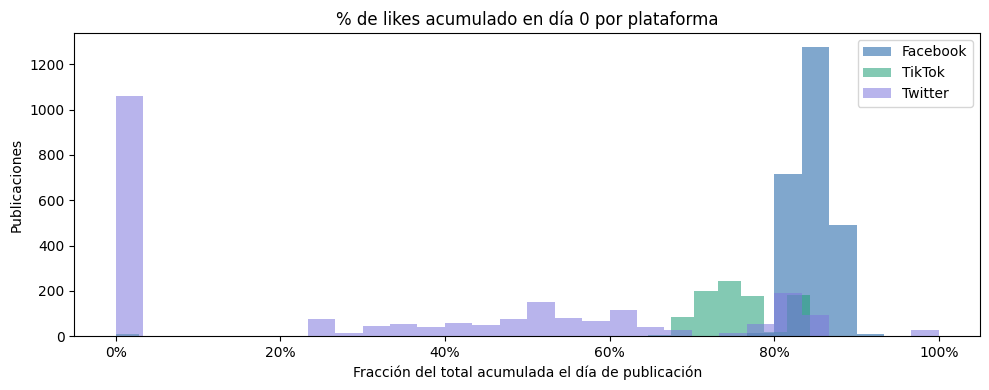

Mediana del % acumulado en día 0:
  Facebook    : 84.7%
  Instagram   : nan%
  TikTok      : 75.0%
  Twitter     : 30.4%


In [8]:
for col_base in tipos_presentes:
    acum_cols = [f'{col_base}_acum_d{d}' for d in DIAS if f'{col_base}_acum_d{d}' in df_out.columns]
    if len(acum_cols) < 2:
        continue
    mat = df_out[acum_cols].values
    viol = (np.diff(mat, axis=1) < 0).any(axis=1).sum()

    col_in_orig = next((c for c, b in INTERACTION_COLS if b == col_base), None)
    if col_in_orig and col_in_orig in df.columns:
        orig = df[col_in_orig].values
        d14  = df_out[f'{col_base}_acum_d14'].values
        err  = np.abs(d14 - orig) / np.maximum(orig, 1)
        print(f'{col_base:15s} | monotonicidad ok: {len(df_out)-viol}/{len(df_out)} '
              f'| error d14 mediano: {np.median(err):.3%} '
              f'| p95: {np.percentile(err, 95):.3%}')

# Distribución del % acumulado en día 0 por plataforma
if 'likes_acum_d0' in df_out.columns and 'likes' in df.columns:
    pct_d0 = df_out['likes_acum_d0'] / df['likes'].clip(lower=1).values

    fig, ax = plt.subplots(figsize=(10, 4))
    for plat, color in COLORS.items():
        mask = (df['platform'] == plat).values
        sub = pct_d0[mask].clip(0, 1)
        if len(sub) > 0:
            ax.hist(sub, bins=30, alpha=0.55, color=color, label=plat)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title('% de likes acumulado en día 0 por plataforma')
    ax.set_xlabel('Fracción del total acumulada el día de publicación')
    ax.set_ylabel('Publicaciones')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Mediana del % acumulado en día 0:')
    for plat in COLORS:
        mask = (df['platform'] == plat).values
        med = pct_d0[mask].median()
        print(f'  {plat:12s}: {med:.1%}')

## 6. Verificación visual

Grafica la curva reconstruida de publicaciones de ejemplo por plataforma.

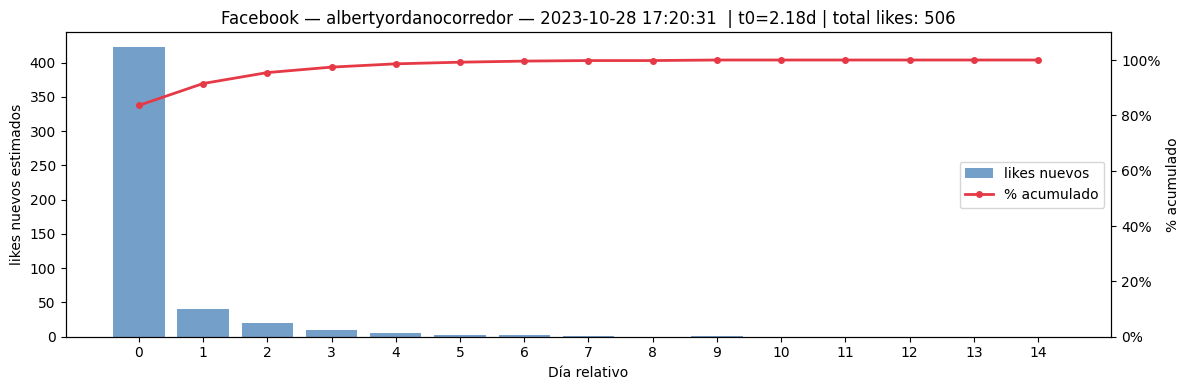

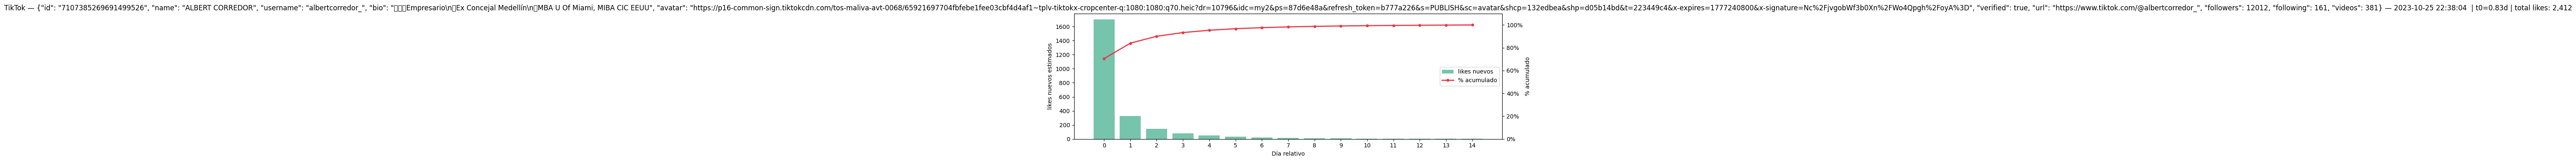

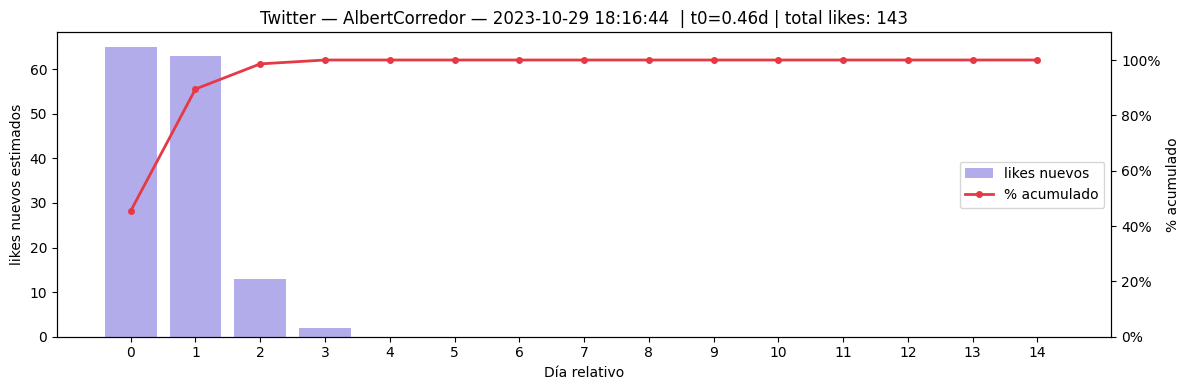

In [9]:
def plot_post(pos, tipo='likes'):
    row = df_out.iloc[pos]
    acum_cols   = [f'{tipo}_acum_d{d}'  for d in DIAS if f'{tipo}_acum_d{d}'  in df_out.columns]
    nuevas_cols = [f'{tipo}_nuevas_d{d}' for d in DIAS if f'{tipo}_nuevas_d{d}' in df_out.columns]
    if not acum_cols:
        print(f'Tipo "{tipo}" no disponible.')
        return

    acum   = row[acum_cols].values.astype(float)
    nuevas = row[nuevas_cols].values.astype(float)
    plat   = row.get('platform', '?')
    color  = COLORS.get(plat, 'steelblue')

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax2 = ax1.twinx()
    ax1.bar(DIAS[:len(acum)], nuevas, color=color, alpha=0.6, label=f'{tipo} nuevos')
    ax2.plot(DIAS[:len(acum)], acum / max(acum[-1], 1),
             color='#E63946', lw=2, marker='o', markersize=4, label='% acumulado')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax2.set_ylim(0, 1.1)
    ax1.set_xticks(DIAS)
    hora  = row.get('hora', '?')
    t0    = row.get('t0_individual', float('nan'))
    total = int(acum[-1]) if len(acum) else 0
    ax1.set_title(
        f"{plat} — {row.get('usuario', '?')} — {row.get('fecha', '?')} {hora}  "
        f"| t0={t0:.2f}d | total {tipo}: {total:,}"
    )
    ax1.set_xlabel('Día relativo')
    ax1.set_ylabel(f'{tipo} nuevos estimados')
    ax2.set_ylabel('% acumulado')
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='center right')
    plt.tight_layout()
    plt.show()

for plat in df['platform'].unique():
    idx_list = df.index[df['platform'] == plat].tolist()
    if idx_list:
        pos = df.index.get_loc(idx_list[0])
        plot_post(pos, tipo='likes')

## 7. Exportación

Genera CSV (liviano) y Excel (con pestaña de resumen por plataforma).

In [10]:
OUTPUT_CSV   = 'panel_historico_reconstruido.csv'

df_out.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f'✓ CSV: {OUTPUT_CSV}  ({len(df_out):,} filas × {len(df_out.columns)} cols)')

# Resumen por plataforma
agg_dict = {'publicaciones': ('total_interacciones', 'count'),
            'total_interacciones': ('total_interacciones', 'sum')}
if 'likes_acum_d0' in df_out.columns:
    agg_dict['likes_acum_d0_median'] = ('likes_acum_d0', 'median')
resumen = df_out.groupby(df['platform'].values).agg(**agg_dict).reset_index()
resumen.columns = ['platform'] + list(resumen.columns[1:])

print()
print('=== Resumen ===')
print(resumen.to_string(index=False))

✓ CSV: panel_historico_reconstruido.csv  (5,776 filas × 340 cols)

=== Resumen ===
platform  publicaciones  total_interacciones  likes_acum_d0_median
Facebook           2511              1367843                 132.0
  TikTok            919              1355383                 102.0
 Twitter           2346              1211915                   2.0


In [12]:
df_out.head()


,id_candidato,red_social,fecha,hora,usuario,texto,url,platform,t0_individual,total_interacciones,...,fb_angry_nuevas_d5,fb_angry_nuevas_d6,fb_angry_nuevas_d7,fb_angry_nuevas_d8,fb_angry_nuevas_d9,fb_angry_nuevas_d10,fb_angry_nuevas_d11,fb_angry_nuevas_d12,fb_angry_nuevas_d13,fb_angry_nuevas_d14
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.182300,513,...,0,0,0,0,0,0,0,0,0,0
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,Facebook,2.223967,1843,...,0,0,0,0,0,0,0,0,0,0
2,COL-05001-010,Facebook,2023-10-28,14:56:44,albertyordanocorredor,Aquí hay una alternativa distinta a Fico y a Q...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.307300,496,...,0,0,0,0,0,0,0,0,0,0
3,COL-05001-010,Facebook,2023-10-28,14:03:34,albertyordanocorredor,"Aquí no hay solamente equipo de trabajo, aquí ...",https://www.facebook.com/reel/889427628897103/,Facebook,2.307300,457,...,0,0,0,0,0,0,0,0,0,0
4,COL-05001-010,Facebook,2023-10-28,12:00:47,albertyordanocorredor,Cuando mis hijos preguntan por qué estamos tra...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.390633,539,...,0,0,0,0,0,0,0,0,0,0
